# Зависимость косинусного расстояния в PCA от перцептивных расстояний

LM Embed shape(1755, 3584)
LM PCA 99-comp shape(1755, 27)
VL Embed shape(1755, 3584)
VL PCA 99-comp shape(1755, 14)


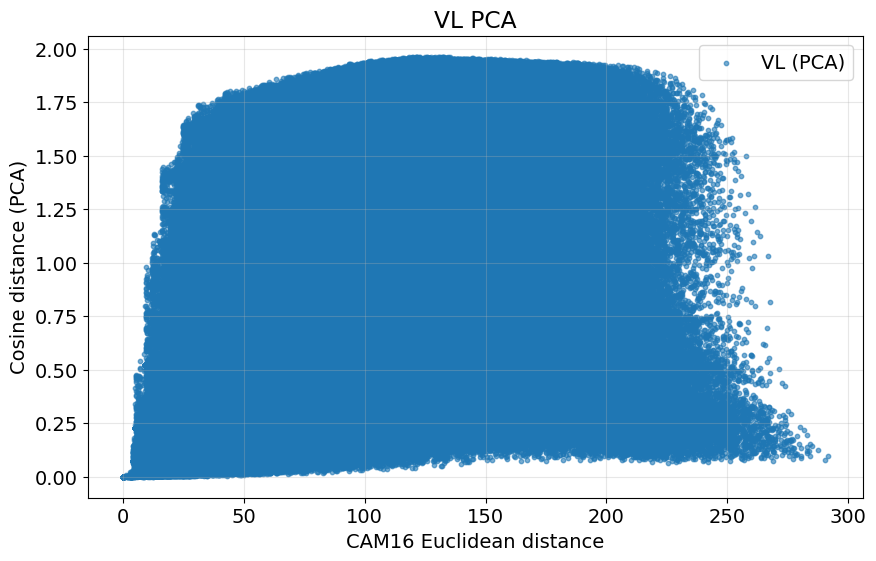

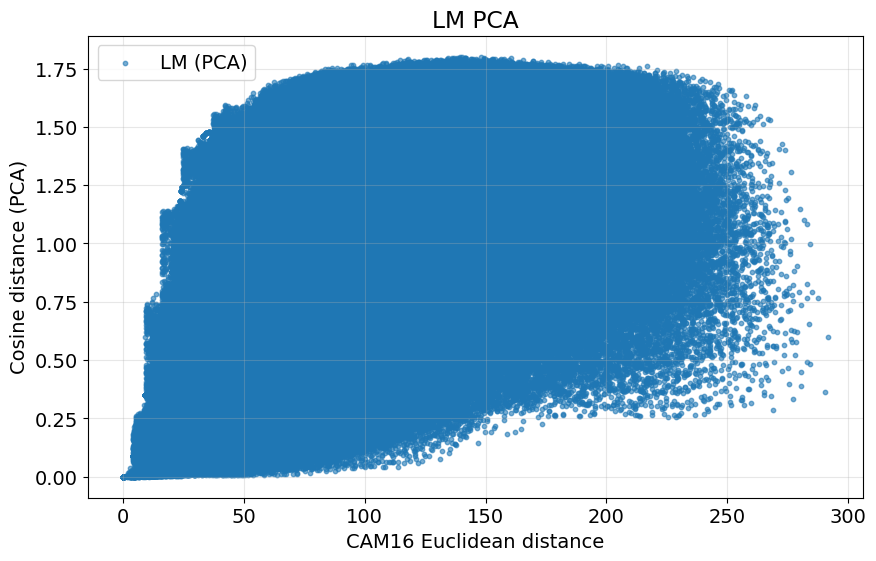

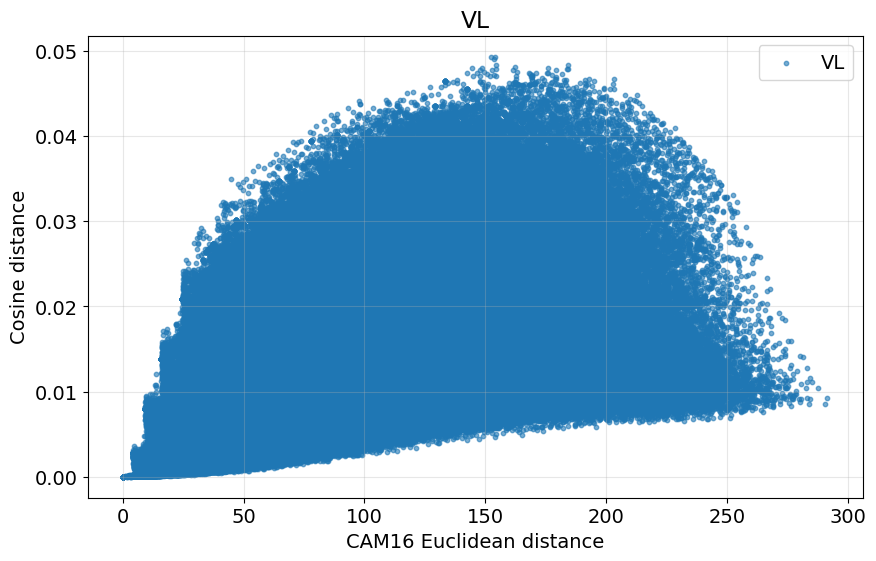

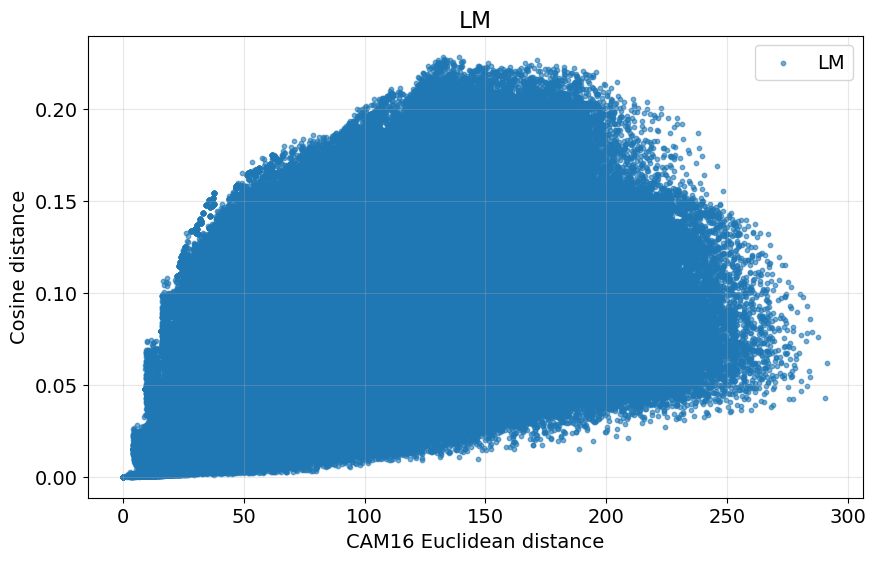

In [2]:
from scipy.spatial.distance import cosine
from colour import xyY_to_XYZ
from colour.models import XYZ_to_CAM16LCD
import numpy as np
from sklearn.metrics import pairwise_distances
import matplotlib.pyplot as plt
from utils.analyze.munsell_analyze import MunsellEmbeddingsAnalyzer

analyzer = MunsellEmbeddingsAnalyzer('data/embeddings/qwen2.5_7B/munsell_colors_describe', 'data/colors/munsell_colors/munsell_manifest.csv')
all_data = analyzer.chain_loader.get_all_available_embeddings()
lm = all_data["lm_pooled"]
vl = all_data["vl_pooled"]
meta = all_data["metadata"] 

pca_result = analyzer.pca_by_embeddings(all_data)
n_components_99_lm = pca_result["lm_pooled"]['n_components_99']
n_components_99_vl = pca_result["vl_pooled"]['n_components_99']

pca_lm = pca_result["lm_pooled"]["pca_result"][:, :n_components_99_lm]
pca_vl = pca_result["vl_pooled"]["pca_result"][:, :n_components_99_vl]

print(f"LM Embed shape{lm.shape}")
print(f"LM PCA 99-comp shape{pca_lm.shape}")

print(f"VL Embed shape{vl.shape}")
print(f"VL PCA 99-comp shape{pca_vl.shape}")

colors_xyY = np.array([
    [item['xyY']['x'], item['xyY']['y'], item['xyY']['Y']]
    for item in meta.values()
], dtype=float)
colors_rgb = np.array([
    [item['RGB']['R'], item['RGB']['G'], item['RGB']['B']]
    for item in meta.values()
], dtype=float)
cam = [XYZ_to_CAM16LCD(xyY_to_XYZ(x)) for x in colors_xyY]

lm_cos_pca = pairwise_distances(pca_lm, metric='cosine')  
vl_cos_pca = pairwise_distances(pca_vl, metric='cosine')   
lm_cos = pairwise_distances(lm, metric='cosine')   
vl_cos = pairwise_distances(vl, metric='cosine')   
cam_dist = pairwise_distances(cam, metric='euclidean') 


# График: косинусное расстояние (PCA) vs CAM для выбранного цета i0
# i0 = 100
# plt.figure(figsize=(10,7))
# plt.scatter(cam_dist[i0], vl_cos_pca[i0], s=30, alpha=0.7, label="VL (PCA)")
# plt.xlabel("CAM16-UCS distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend(); plt.grid(True, alpha=0.3)
# plt.show()

# i0 = 100
# plt.figure(figsize=(10,7))
# plt.scatter(cam_dist[i0], lm_cos_pca[i0], s=30, alpha=0.7, label="LM (PCA)")
# plt.xlabel("CAM16-UCS distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend(); plt.grid(True, alpha=0.3)
# plt.show()


tri = np.triu_indices_from(cam_dist, k=1)

# График: сравнение косинусное расстояние vs CAM для исходных эмбедов и после pca 
# plt.figure(figsize=(10, 6))
# plt.scatter(cam_dist[tri], vl_cos_pca[tri], s=10, alpha=0.6, label="VL (PCA)")
# plt.scatter(cam_dist[tri], vl_cos[tri], s=10, alpha=0.6, label="VL")
# plt.xlabel("CAM16 Euclidean distance")
# plt.ylabel("Cosine distance (PCA)")
# plt.legend()
# plt.title('VL/LM PCA')
# plt.grid(True, alpha=0.3)
# plt.show()


###

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], vl_cos_pca[tri], s=10, alpha=0.6, label="VL (PCA)")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance (PCA)")
plt.legend()
plt.title('VL PCA')
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], lm_cos_pca[tri], s=10, alpha=0.6, label="LM (PCA)")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance (PCA)")
plt.legend()
plt.title('LM PCA')
plt.grid(True, alpha=0.3)
plt.show()

###

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], vl_cos[tri], s=10, alpha=0.6, label="VL")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance")
plt.title('VL')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(cam_dist[tri], lm_cos[tri], s=10, alpha=0.6, label="LM")
plt.xlabel("CAM16 Euclidean distance")
plt.ylabel("Cosine distance")
plt.title('LM')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [3]:
from scipy.stats import spearmanr, pearsonr

x = cam_dist[tri]          
y_vl = vl_cos[tri]
y_vl_pca = vl_cos_pca[tri]
y_lm = lm_cos[tri]
y_lm_pca = lm_cos_pca[tri]

def corr_report(name, y):
    sp = spearmanr(x, y).correlation
    pr = pearsonr(x, y).statistic
    print(f"{name:10s} | Spearman ρ={sp:.4f} | Pearson r={pr:.4f}")

corr_report("VL", y_vl)
corr_report("VL_PCA", y_vl_pca)
corr_report("LM", y_lm)
corr_report("LM_PCA", y_lm_pca)


VL         | Spearman ρ=0.6081 | Pearson r=0.5288
VL_PCA     | Spearman ρ=0.4803 | Pearson r=0.4352
LM         | Spearman ρ=0.5596 | Pearson r=0.5157
LM_PCA     | Spearman ρ=0.5668 | Pearson r=0.5546


# Проверка корретности обучения на эмбедингах VLM для предсказания cam координат

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import pearsonr

X_base = np.asarray(colors_rgb, dtype=float)
Y = np.asarray(cam, dtype=float)
target_features = 1000


def make_rootpoly(rgb, total_feats=33, seed=0):
    """
    Генерирует total_feats признаков: первые 3 — исходные r,g,b,
    остальные — случайные произвежения r^a * g^b * b^c, a+b+c=1.
    """
    assert total_feats >= 3
    rng = np.random.default_rng(seed)
    r, g, b = rgb[:, 0], rgb[:, 1], rgb[:, 2]

    base = np.stack([r, g, b], axis=1)  # (N,3)
    n_extra = total_feats - 3

    exps = rng.dirichlet(np.ones(3), size=n_extra)  # (n_extra,3), сумма = 1
    extra = (r[:, None] ** exps[:, 0]) * (g[:, None] ** exps[:, 1]) * (b[:, None] ** exps[:, 2])  # (N, n_extra)

    return np.hstack([base, extra])  # shape (N, total_feats)


def pad_to_dim(X, target_dim, noise_std=0.05, seed=0):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    if d >= target_dim:
        return X[:, :target_dim]
    pad = rng.normal(0, noise_std, size=(n, target_dim - d))
    return np.hstack([X, pad])

# строим варианты
X_rgb = pad_to_dim(X_base, target_features, noise_std=0.0, seed=1)         
X_rootpoly = pad_to_dim(make_rootpoly(X_base, total_feats=2000, seed=1), target_features, seed=2)     
X_noise = pad_to_dim(X_base, target_features, noise_std=0.05, seed=3)     

def eval_reg(X, y, name):
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
    reg = LinearRegression().fit(Xtr, ytr)
    ytr_pred, yte_pred = reg.predict(Xtr), reg.predict(Xte)
    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]
    metrics = dict(
        rmse_train = root_mean_squared_error(ytr, ytr_pred),
        rmse_test  = root_mean_squared_error(yte, yte_pred),
        r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
        r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
    )
    print(f"[{name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f}")
    return metrics, reg

lm  = np.asarray(lm,  dtype=float)
vl  = np.asarray(vl,  dtype=float)
lm_pca  = np.asarray(pca_lm,  dtype=float)
vl_pca  = np.asarray(pca_vl,  dtype=float)
cam = np.asarray(cam, dtype=float)

print("----Linear Regression----")
m_lm_pca, reg_lm = eval_reg(lm_pca, cam, "lm_pca")
m_vl_pca, reg_vl = eval_reg(vl_pca, cam, "vl_pca")
m_lm, reg_lm = eval_reg(lm, cam, "lm")
m_vl, reg_vl = eval_reg(vl, cam, "vl")
m_rgb, reg_rgb         = eval_reg(X_base,      Y, "RGB")
m_rootpoly, reg_rp     = eval_reg(X_rootpoly, Y, "Root-poly (33) + noise to 2000")
m_noise, reg_noise     = eval_reg(X_noise,    Y, "RGB + noise to 2000")


----Linear Regression----
[lm_pca] RMSE train/test: 4.6791/4.2399 | R2: 0.9864/0.9884 | Corr: 0.9985/0.9988
[vl_pca] RMSE train/test: 6.2254/6.0420 | R2: 0.9784/0.9791 | Corr: 0.9977/0.9978
[lm] RMSE train/test: 0.0000/1.0711 | R2: 1.0000/0.9993 | Corr: 1.0000/0.9999
[vl] RMSE train/test: 0.0000/1.3655 | R2: 1.0000/0.9990 | Corr: 1.0000/0.9999
[RGB] RMSE train/test: 11.5913/11.5928 | R2: 0.9290/0.9261 | Corr: 0.9924/0.9921
[Root-poly (33) + noise to 2000] RMSE train/test: 8.8014/118.9765 | R2: 0.9581/-8.6061 | Corr: 0.9955/0.6030
[RGB + noise to 2000] RMSE train/test: 6.0709/21.3521 | R2: 0.9806/0.7500 | Corr: 0.9979/0.9736


In [5]:
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

def eval_mlp(X, y, name, hidden=(512, 256, 128), lr=1e-3, max_iter=500, seed=42):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=seed, shuffle=True)

    mlp = make_pipeline(
        StandardScaler(),
        MLPRegressor(
            hidden_layer_sizes=hidden,
            activation='relu',
            solver='adam',
            alpha=1e-4,
            learning_rate_init=lr,
            max_iter=max_iter,
            batch_size=128,
            random_state=seed,
            early_stopping=True,
            n_iter_no_change=20,
            verbose=False,
        )
    )
    mlp.fit(Xtr, ytr)

    ytr_pred, yte_pred = mlp.predict(Xtr), mlp.predict(Xte)

    def corr(a, b):
        return pearsonr(a.reshape(-1), b.reshape(-1))[0]

    metrics = dict(
        rmse_train = root_mean_squared_error(ytr, ytr_pred),
        rmse_test  = root_mean_squared_error(yte, yte_pred),
        r2_train   = r2_score(ytr, ytr_pred, multioutput="variance_weighted"),
        r2_test    = r2_score(yte, yte_pred, multioutput="variance_weighted"),
        corr_train = corr(ytr, ytr_pred),
        corr_test  = corr(yte, yte_pred),
        model      = mlp,
    )
    print(f"[MLP {name}] RMSE train/test: {metrics['rmse_train']:.4f}/{metrics['rmse_test']:.4f} | "
          f"R2: {metrics['r2_train']:.4f}/{metrics['r2_test']:.4f} | "
          f"Corr: {metrics['corr_train']:.4f}/{metrics['corr_test']:.4f}")
    return metrics

# Сравнение результатов обучения MLP
mlp_lm     = eval_mlp(lm,      cam, "lm")
mlp_vl     = eval_mlp(vl,      cam, "vl")
mlp_lm_pca = eval_mlp(lm_pca,  cam, "lm_pca")
mlp_vl_pca = eval_mlp(vl_pca,  cam, "vl_pca")
mlp_lm_pca = eval_mlp(X_base,  Y, "rgb")
mlp_lm_pca = eval_mlp(X_rootpoly,  Y, "root poly")


[MLP lm] RMSE train/test: 0.9215/1.1758 | R2: 0.9996/0.9992 | Corr: 1.0000/0.9999
[MLP vl] RMSE train/test: 0.8562/1.1679 | R2: 0.9996/0.9992 | Corr: 1.0000/0.9999
[MLP lm_pca] RMSE train/test: 1.0906/1.7860 | R2: 0.9993/0.9980 | Corr: 0.9999/0.9998
[MLP vl_pca] RMSE train/test: 1.2798/1.5516 | R2: 0.9991/0.9986 | Corr: 0.9999/0.9999
[MLP rgb] RMSE train/test: 1.4743/1.5350 | R2: 0.9988/0.9987 | Corr: 0.9999/0.9999
[MLP root poly] RMSE train/test: 1.3795/1.5316 | R2: 0.9989/0.9985 | Corr: 0.9999/0.9998


# Обучение отображения A с сохранением расстояния для функции $$\Sigma_{i,j}(||A(x_i-x_j)||^2 - ||y_i-y_j||^2)^2$$

In [6]:
lm.shape, vl.shape

((1755, 3584), (1755, 3584))

LM layer: R² = 0.9996, RMSE = 0.9007
LM layer:
  Rmse(dist_true, dist_pred) = 0.6505
  Pearson(dist_true, dist_pred) = 0.9998 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9998 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5157 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.5596 (p = 0.00e+00)
  Pearson(dist_emb, dist_pred)   = 0.5159 (p = 0.00e+00)


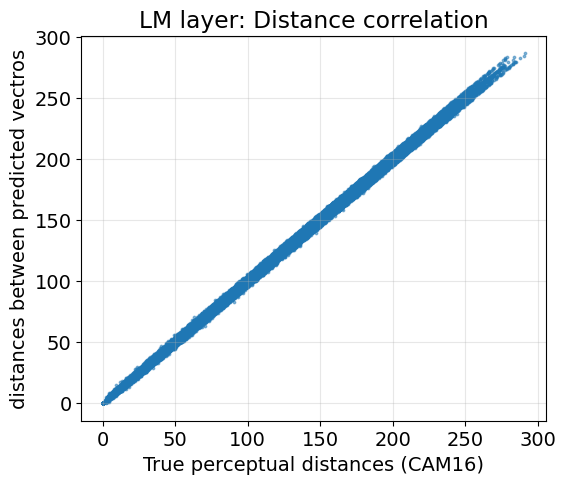

LM layer: Matrix W shape = (3, 3584), Bias b shape = (3,)
Vision layer: R² = 0.9989, RMSE = 1.4438
Vision layer:
  Rmse(dist_true, dist_pred) = 5.1965
  Pearson(dist_true, dist_pred) = 0.9986 (p = 0.00e+00)
  Spearman(dist_true, dist_pred) = 0.9986 (p = 0.00e+00)
  Pearson(dist_emb, dist_true)   = 0.5288 (p = 0.00e+00)
  Spearman(dist_emb, dist_true)  = 0.6081 (p = 0.00e+00)
  Pearson(dist_emb, dist_pred)   = 0.5277 (p = 0.00e+00)


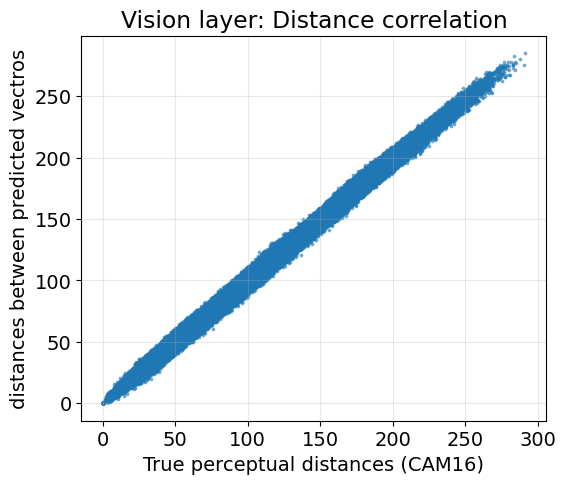

Vision layer: Matrix W shape = (3, 3584), Bias b shape = (3,)
Correlation between LM and Vision predicted colors:
  Pearson = 0.9999
  Spearman = 0.9998


In [6]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, pairwise_distances
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

def linear_color_mapping(embeddings, colors_cam, layer_name="LM"):
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, colors_cam, test_size=0.2, random_state=42
    )

    # Линейное отображение
    reg = Ridge(alpha=1.0)
    reg.fit(X_train, y_train)
    y_pred_test = reg.predict(X_test)
    y_pred_all = reg.predict(embeddings)

    # Оценка точности
    r2 = r2_score(y_test, y_pred_test, multioutput='variance_weighted')
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    print(f"{layer_name} layer: R² = {r2:.4f}, RMSE = {rmse:.4f}")

    # анализ через pairwise distances
    D_emb = pairwise_distances(embeddings, metric='cosine')
    D_true = pairwise_distances(colors_cam, metric='euclidean')
    D_pred = pairwise_distances(y_pred_all, metric='euclidean')

    n = embeddings.shape[0]
    triu_idx = np.triu_indices(n, k=1)
    v_emb = D_emb[triu_idx]
    v_true = D_true[triu_idx]
    v_pred = D_pred[triu_idx]

    # pearson_true_pred = pearsonr(v_true, v_pred)[0]
    # spearman_true_pred = spearmanr(v_true, v_pred).correlation
    # pearson_emb_true = pearsonr(v_emb, v_true)[0]
    # spearman_emb_true = spearmanr(v_emb, v_true)[0]
    # pearson_emb_pred = pearsonr(v_emb, v_pred)[0]


    # print(f"{layer_name} layer:")
    # print(f"  Pearson(dist_true, dist_pred) = {pearson_true_pred:.4f}")
    # print(f"  Spearman(dist_true, dist_pred) = {spearman_true_pred:.4f}")
    # print(f"  Pearson(dist_emb, dist_true)   = {pearson_emb_true:.4f}")
    # print(f"  Spearman(dist_emb, dist_true)   = {spearman_emb_true:.4f}")
    # print(f"  Pearson(dist_emb, dist_pred)   = {pearson_emb_pred:.4f}")

    dist_rmse = mean_squared_error(v_true, v_pred)
    pearson_r, pearson_p = pearsonr(v_true, v_pred)
    spearman_res = spearmanr(v_true, v_pred)
    spearman_r = getattr(spearman_res, 'correlation', spearman_res.statistic)
    spearman_p = spearman_res.pvalue

    emb_true_pr, emb_true_pp = pearsonr(v_emb, v_true)
    emb_true_sr = spearmanr(v_emb, v_true)
    emb_true_sr_r = getattr(emb_true_sr, 'correlation', emb_true_sr.statistic)
    emb_true_sr_p = emb_true_sr.pvalue

    emb_pred_pr, emb_pred_pp = pearsonr(v_emb, v_pred)

    print(f"{layer_name} layer:")
    print(f"  Rmse(dist_true, dist_pred) = {dist_rmse:.4f}")
    print(f"  Pearson(dist_true, dist_pred) = {pearson_r:.4f} (p = {pearson_p:.2e})")
    print(f"  Spearman(dist_true, dist_pred) = {spearman_r:.4f} (p = {spearman_p:.2e})")
    print(f"  Pearson(dist_emb, dist_true)   = {emb_true_pr:.4f} (p = {emb_true_pp:.2e})")
    print(f"  Spearman(dist_emb, dist_true)  = {emb_true_sr_r:.4f} (p = {emb_true_sr_p:.2e})")
    print(f"  Pearson(dist_emb, dist_pred)   = {emb_pred_pr:.4f} (p = {emb_pred_pp:.2e})")



    plt.figure(figsize=(6,5))
    plt.scatter(v_true, v_pred, s=3, alpha=0.5)
    plt.xlabel('True perceptual distances (CAM16)')
    plt.ylabel('distances between predicted vectros')
    plt.title(f'{layer_name} layer: Distance correlation')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Матрица линейного преобразования и bias
    W = reg.coef_
    b = reg.intercept_
    print(f"{layer_name} layer: Matrix W shape = {W.shape}, Bias b shape = {b.shape}")

    return y_pred_all, W, b

# === LM layer ===
y_pred_lm, W_lm, b_lm = linear_color_mapping(lm, cam, layer_name="LM")

# === Vision layer ===
y_pred_vl, W_vl, b_vl = linear_color_mapping(vl, cam, layer_name="Vision")

# === Корреляция между предсказанными цветами двух слоёв ===
pearson_between_layers = pearsonr(
    y_pred_lm.flatten(), y_pred_vl.flatten()
)[0]
spearman_between_layers = spearmanr(
    y_pred_lm.flatten(), y_pred_vl.flatten()
).correlation


print(f"Correlation between LM and Vision predicted colors:")
print(f"  Pearson = {pearson_between_layers:.4f}")
print(f"  Spearman = {spearman_between_layers:.4f}")


In [7]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_squared_error

# ============================================================
# 1) Pair sampling utilities for distance-matching objective
# ============================================================

def sample_pairs_uniform(n, n_pairs, seed=42):
    """Uniformly sample (i,j) with i<j."""
    rng = np.random.default_rng(seed)
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    # avoid i==j
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2


def make_pair_batch(X, Y, i, j):
    """
    X: (n,d), Y: (n,3)
    returns:
      V: (B,d)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2
      t :(B,)   = ||Y[i]-Y[j]||
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))
    return V, t2, t

# ============================================================
# 2) Objective: match squared distances via A (A in R^{3xd})
#    L = sum ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared(A, V, t2, weights=None):
    """
    A: (3,d)
    V: (B,d)
    t2: (B,)
    weights: (B,) or None

    returns:
      loss (float), gradA (3,d)
    """
    AV = V @ A.T                 
    s = np.sum(AV * AV, axis=1)  
    e = (s - t2)                 

    if weights is not None:
        w = weights
        loss = np.mean(w * (e * e))
        c = 4.0 * w * e                      
    else:
        loss = np.mean(e * e)
        c = 4.0 * e
    grad = ( (c[:, None] * AV).T @ V ) / V.shape[0]   # (3,d)

    return float(loss), grad

def fit_A_with_normalization(
    X, Y_cam, W_init=None,
    n_pairs=500_000,
    batch_size=2048,
    n_steps=3000,
    lr=1e-3,
    seed=42,
    verbose_every=200,
    grad_clip=10.0,
):
    rng = np.random.default_rng(seed)
    n, d = X.shape
    
    #  Нормализация X 
    scaler_X = StandardScaler()
    X_norm = scaler_X.fit_transform(X)
    
    # Нормализация Y (важно для t²!) 
    scaler_Y = StandardScaler()
    Y_norm = scaler_Y.fit_transform(Y_cam)
    
    print(f"После нормализации:")
    print(f"  X_norm: range=[{X_norm.min():.2f}, {X_norm.max():.2f}], std={X_norm.std():.4f}")
    print(f"  Y_norm: range=[{Y_norm.min():.2f}, {Y_norm.max():.2f}], std={Y_norm.std():.4f}")
    
    # Проверяем t² после нормализации
    i_test, j_test = sample_pairs_uniform(n, 5000, seed=0)
    _, t2_test, _ = make_pair_batch(X_norm, Y_norm, i_test, j_test)
    print(f"  t² после норм.: min={t2_test.min():.2f}, max={t2_test.max():.2f}, mean={t2_test.mean():.2f}")
    
    # Инициализация A 
    if W_init is not None:
        sigma_x = scaler_X.scale_  # (d,)
        sigma_y = scaler_Y.scale_  # (3,)
        
        A = (W_init * sigma_x[None, :]) / sigma_y[:, None]
        print(f"  A init from W: ||A||={np.linalg.norm(A):.4f}")
    else:
        A = np.sqrt(2.0 / (d + 3)) * rng.standard_normal((3, d))
        print(f"  A random init: ||A||={np.linalg.norm(A):.4f}")
    
    # === 4. Обучение ===
    i_all, j_all = sample_pairs_uniform(n, n_pairs, seed=seed)
    n_batches = int(np.ceil(n_pairs / batch_size))
    
    for step in range(n_steps):
        b_idx = step % n_batches
        sl = slice(b_idx * batch_size, min((b_idx + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]
        V, t2, _ = make_pair_batch(X_norm, Y_norm, i, j)
        
        loss, grad = loss_and_grad_A_squared(A, V, t2)
        
        # Gradient clipping
        gnorm = np.linalg.norm(grad)
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / gnorm)

        if np.isnan(loss):
            print(f"NaN at step {step}! ||A||={np.linalg.norm(A):.2e}, ||grad||={gnorm:.2e}")
            break
        
        A = A - lr * grad
        
        if (step + 1) % verbose_every == 0:
            print(f"step={step+1}/{n_steps} loss={loss:.6f} ||grad||={gnorm:.4f} ||A||={np.linalg.norm(A):.4f}")
    
    # === 5. Преобразуем A обратно в исходный масштаб ===
    # A_orig: y = A_orig @ x (в исходных координатах, без bias)
    # y_norm = A @ x_norm
    # (y - μ_y)/σ_y = A @ (x - μ_x)/σ_x
    # y = σ_y * A @ (x - μ_x)/σ_x + μ_y
    # y = (σ_y[:, None] * A / σ_x[None, :]) @ x + (μ_y - σ_y * A @ μ_x / σ_x)
    
    sigma_x = scaler_X.scale_
    sigma_y = scaler_Y.scale_
    mu_x = scaler_X.mean_
    mu_y = scaler_Y.mean_
    
    A_orig = (sigma_y[:, None] * A) / sigma_x[None, :]
    b_orig = mu_y - A_orig @ mu_x
    
    return A, A_orig, b_orig, scaler_X, scaler_Y


def evaluate_with_normalization(X, Y_cam, A_norm, scaler_X, scaler_Y, 
                                n_eval_pairs=200_000, seed=0, title=""):
    """Оценка на нормализованных данных"""
    X_norm = scaler_X.transform(X)
    Y_norm = scaler_Y.transform(Y_cam)
    
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, seed=seed)
    V, t2, t = make_pair_batch(X_norm, Y_norm, i, j)
    
    AV = V @ A_norm.T
    s = np.sum(AV * AV, axis=1)
    pred = np.sqrt(np.maximum(s, 0.0))
    
    rmse = np.sqrt(mean_squared_error(t, pred))
    pr, _ = pearsonr(t, pred)
    sr = spearmanr(t, pred)
    sr_r = getattr(sr, 'correlation', sr.statistic)
    
    print(f"\n{title}")
    print(f"  RMSE (normalized) = {rmse:.4f}")
    print(f"  Pearson  = {pr:.4f}")
    print(f"  Spearman = {sr_r:.4f}")
    
    # Также в исходном масштабе
    Y_pred_norm = X_norm @ A_norm.T
    Y_pred = scaler_Y.inverse_transform(Y_pred_norm)
    
    D_true = np.sqrt(np.sum((Y_cam[i] - Y_cam[j])**2, axis=1))
    D_pred = np.sqrt(np.sum((Y_pred[i] - Y_pred[j])**2, axis=1))
    
    rmse_orig = np.sqrt(mean_squared_error(D_true, D_pred))
    pr_orig, _ = pearsonr(D_true, D_pred)
    
    print(f"  RMSE (original scale) = {rmse_orig:.4f}")
    print(f"  Pearson (original)    = {pr_orig:.4f}")
    
    return {"rmse_norm": rmse, "rmse_orig": rmse_orig, "pearson": pr, "spearman": sr_r}


def run_full_experiment(embeddings, Y_cam, layer_name="LM"):
    from sklearn.linear_model import Ridge
    from sklearn.model_selection import train_test_split
    from sklearn.metrics import r2_score

    # Baseline Ridge regression
    X_train, X_test, y_train, y_test = train_test_split(
        embeddings, Y_cam, test_size=0.2, random_state=42
    )
    reg = Ridge(alpha=1.0)
    reg.fit(X_train, y_train)
    y_pred = reg.predict(X_test)
    W = reg.coef_
    b = reg.intercept_
    
    D_pred = pairwise_distances(y_pred, metric='euclidean')
    D_true = pairwise_distances(y_test, metric='euclidean')
    dist_rmse = np.sqrt(mean_squared_error(D_pred, D_true))

    r2 = r2_score(y_test, reg.predict(X_test), multioutput='variance_weighted')
    rmse = np.sqrt(mean_squared_error(y_test, reg.predict(X_test)))
    print(f"{layer_name}: Ridge R² = {r2:.4f}, rmse: {rmse:.2f}, dist_rmse: {dist_rmse:.4f}")
    
    print(f"\n{'='*50}")
    print(f"Init from W (Ridge)")
    print(f"{'='*50}")
    
    A2_norm, A2_orig, b2_orig, sc_X, sc_Y = fit_A_with_normalization(
        embeddings, Y_cam, W_init=W,
        n_pairs=500_000,
        batch_size=2048,
        n_steps=2000,
        lr=1e-4,  
        grad_clip=5.0,
        verbose_every=400
    )
    res2 = evaluate_with_normalization(embeddings, Y_cam, A2_norm, sc_X, sc_Y,
                                       title=f"{layer_name} | Init from W")
    
    # === Baseline W evaluation ===
    print(f"\n{'='*50}")
    print(f"Baseline W (Ridge) for comparison")
    print(f"{'='*50}")
    
    # Трансформируем W в нормализованное пространство
    sigma_x = sc_X.scale_
    sigma_y = sc_Y.scale_
    W_norm = (W * sigma_x[None, :]) / sigma_y[:, None]
    
    res_base = evaluate_with_normalization(embeddings, Y_cam, W_norm, sc_X, sc_Y,
                                           title=f"{layer_name} | Baseline W")
    
    return {
        "A_norm": A2_norm, "A2_orig": A2_orig, "res2": res2,
        "W": W, "W_norm": W_norm, "res_baseline": res_base,
        "scaler_X": sc_X, "scaler_Y": sc_Y
    }


# ===========================================================

out_lm = run_full_experiment(lm, cam, layer_name="LM")
# print('\n', '='*100, '\n')
# out_vl = run_full_experiment(vl, cam, layer_name="Vision")

LM: Ridge R² = 0.9996, rmse: 0.90, dist_rmse: 1.4260

Init from W (Ridge)
После нормализации:
  X_norm: range=[-4.93, 4.76], std=1.0000
  Y_norm: range=[-2.91, 2.62], std=1.0000
  t² после норм.: min=0.00, max=33.13, mean=6.08
  A init from W: ||A||=0.9575
step=400/2000 loss=0.011792 ||grad||=23.4247 ||A||=0.9576
step=800/2000 loss=0.011415 ||grad||=23.4896 ||A||=0.9576
step=1200/2000 loss=0.012375 ||grad||=24.6352 ||A||=0.9576
step=1600/2000 loss=0.011939 ||grad||=26.0353 ||A||=0.9577
step=2000/2000 loss=0.013155 ||grad||=25.3752 ||A||=0.9577

LM | Init from W
  RMSE (normalized) = 0.0199
  Pearson  = 0.9998
  Spearman = 0.9998
  RMSE (original scale) = 0.8435
  Pearson (original)    = 0.9998

Baseline W (Ridge) for comparison

LM | Baseline W
  RMSE (normalized) = 0.0181
  Pearson  = 0.9998
  Spearman = 0.9998
  RMSE (original scale) = 0.8036
  Pearson (original)    = 0.9998


# Построение преобразвоания которое приближает расстояние между эмбедингами к психофизическому

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# 0) Utils

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V: (B,n)  = X[i]-X[j]
      t2:(B,)   = ||Y[i]-Y[j]||^2   (Y is 3D)
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2



# 1) Objective for FULL A (n x n)
#    L = mean ( ||A v||^2 - t2 )^2
#    grad_A = 4 * mean( e * (A v) v^T )


def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            
    e = (s - t2)                         
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)  
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])  
    return loss, grad


# 2) AdamW + grad clipping

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1

        # decoupled weight decay
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# 3) Validation metrics (MAE/MAPE/sMAPE) + correlations

def regression_errors(y_true, y_pred, eps=1e-6):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)

    err = y_pred - y_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(y_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)

    smape = float(
        np.mean(2.0 * np.abs(err) / np.maximum(np.abs(y_true) + np.abs(y_pred), eps)) * 100.0
    )
    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape}

def compute_pred_true_for_pairs(X, Y, A, i, j, eps=1e-12):
    """
      t2, pred2, t, pred
    """
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    m = np.isfinite(t2) & np.isfinite(pred2) & np.isfinite(t) & np.isfinite(pred)
    return {
        "t2": t2[m], "pred2": pred2[m],
        "t": t[m], "pred": pred[m]
    }

def eval_alignment_fullA(X, Y, A, n_eval_pairs=80_000, seed=0, eps=1e-6, mode="sq"):
    """
    mode:
      "sq"   -> compare t2=||Δy||^2 with pred2=||AΔx||^2
      "dist" -> compare t =||Δy||   with pred =||AΔx||
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    d = compute_pred_true_for_pairs(X, Y, A, i, j)

    if mode == "sq":
        y_true, y_pred = d["t2"], d["pred2"]
    elif mode == "dist":
        y_true, y_pred = d["t"], d["pred"]
    else:
        raise ValueError("mode must be 'sq' or 'dist'")

    errs = regression_errors(y_true, y_pred, eps=eps)

    pr = float(pearsonr(y_true, y_pred)[0])
    sr = spearmanr(y_true, y_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    return {**errs, "pearson": pr, "spearman": sr_r}

def estimate_val_loss_sq(X, Y, A, n_eval_pairs=80_000, seed=0):
    """
    Validation loss as training:
      mean( (||AΔx||^2 - ||Δy||^2)^2 )
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t2 = make_pair_batch(X, Y, i, j)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))

# 4) Init: A = alpha * I

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)    
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop with validation metrics, best step by VAL LOSS

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    # logging
    log_every=50,
    val_every=200,
    n_val_pairs=80_000,
    # early stopping by val loss (objective)
    patience=5,
    min_delta=0.0,
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []
    hist_val_sq_rmse, hist_val_dist_rmse = [], []

    # best checkpoint by VAL LOSS (objective units)
    best = {
        "val_loss": np.inf,
        "A": A.copy(),
        "step": 0,
        "val_metrics_sq": None,
        "val_metrics_dist": None,
    }
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            # --- Val loss (objective) ---
            val_loss = estimate_val_loss_sq(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step)

            # --- Extra metrics (sq + dist) ---
            val_sq = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 10, mode="sq")
            val_d  = eval_alignment_fullA(X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 11, mode="dist")

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)
            hist_val_sq_rmse.append(val_sq["rmse"])
            hist_val_dist_rmse.append(val_d["rmse"])

            print(f"step={step}/{n_steps} "
                  f"train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")

            print(f"  [val sq]   RMSE={val_sq['rmse']:.3f} MAE={val_sq['mae']:.3f} "
                  f"MAPE={val_sq['mape']:.2f}% sMAPE={val_sq['smape']:.2f}% "
                  f"Pearson={val_sq['pearson']:.4f} Spearman={val_sq['spearman']:.4f}")

            print(f"  [val dist] RMSE={val_d['rmse']:.3f} MAE={val_d['mae']:.3f} "
                  f"MAPE={val_d['mape']:.2f}% sMAPE={val_d['smape']:.2f}% "
                  f"Pearson={val_d['pearson']:.4f} Spearman={val_d['spearman']:.4f}")

            # --- early stopping & best checkpoint by val_loss ---
            if val_loss < best["val_loss"] - min_delta:
                best = {
                    "val_loss": val_loss,
                    "A": A.copy(),
                    "step": step,
                    "val_metrics_sq": val_sq,
                    "val_metrics_dist": val_d,
                }
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: "
                          f"no improvement in VAL LOSS for {patience} validations. "
                          f"Best step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # ---- plots ----
    plt.figure(figsize=(7, 4))
    plt.plot(hist_train_steps, hist_train_loss, label="train loss (batch)")
    if len(hist_val_steps) > 0:
        plt.plot(hist_val_steps, hist_val_loss, marker="o", label="val loss (objective)")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("Training vs Validation objective loss")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    plt.figure(figsize=(7, 4))
    if len(hist_val_steps) > 0:
        plt.plot(hist_val_steps, hist_val_sq_rmse, marker="o", label="val RMSE on t²")
        plt.plot(hist_val_steps, hist_val_dist_rmse, marker="o", label="val RMSE on t")
    plt.xlabel("step")
    plt.ylabel("RMSE")
    plt.title("Validation RMSE (squared distances vs distances)")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_metrics_sq"] is not None:
        sq = best["val_metrics_sq"]
        d = best["val_metrics_dist"]
        print(f"  [best val sq]   RMSE={sq['rmse']:.3f} MAE={sq['mae']:.3f} MAPE={sq['mape']:.2f}% sMAPE={sq['smape']:.2f}% "
              f"Pearson={sq['pearson']:.4f} Spearman={sq['spearman']:.4f}")
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": np.array(hist_train_steps, dtype=int),
        "train_loss": np.array(hist_train_loss, dtype=float),
        "val_steps": np.array(hist_val_steps, dtype=int),
        "val_loss": np.array(hist_val_loss, dtype=float),
        "val_sq_rmse": np.array(hist_val_sq_rmse, dtype=float),
        "val_dist_rmse": np.array(hist_val_dist_rmse, dtype=float),
    }
    return best, history


# ============================================================
# 6) Scatter plot: ||AΔx|| vs ||Δy||
# ============================================================

def plot_distance_scatter(X, Y, A, n_plot_pairs=60_000, seed=123, title=""):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_plot_pairs, rng)

    dY = Y[i] - Y[j]
    d_true = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    d_pred = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

    pr = float(pearsonr(d_true, d_pred)[0])
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    plt.figure(figsize=(6, 5))
    plt.scatter(d_true, d_pred, s=3, alpha=0.35)
    plt.xlabel("True distance  ||Δy||  (CAM16)")
    plt.ylabel("Pred distance  ||AΔx||")
    plt.title(title + f"\nPearson={pr:.4f}, Spearman={sr_r:.4f}")
    plt.grid(True, alpha=0.3)
    plt.show()

    return {"pearson_dist": pr, "spearman_dist": sr_r}


# ============================================================
# 7) runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=200,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        n_val_pairs=n_val_pairs,
        patience=patience,
        min_delta=min_delta,
    )

    A_best = best["A"]

    # FINAL evaluation on test, using additional metrics (but not for selection)
    final_loss = estimate_val_loss_sq(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    final_sq = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1001, mode="sq")
    final_d  = eval_alignment_fullA(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1002, mode="dist")

    print(f"[{layer_name}] FINAL test objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL test (sq):   RMSE={final_sq['rmse']:.3f} MAE={final_sq['mae']:.3f} "
          f"MAPE={final_sq['mape']:.2f}% sMAPE={final_sq['smape']:.2f}% "
          f"Pearson={final_sq['pearson']:.4f} Spearman={final_sq['spearman']:.4f}")
    print(f"[{layer_name}] FINAL test (dist): RMSE={final_d['rmse']:.3f} MAE={final_d['mae']:.3f} "
          f"MAPE={final_d['mape']:.2f}% sMAPE={final_d['smape']:.2f}% "
          f"Pearson={final_d['pearson']:.4f} Spearman={final_d['spearman']:.4f}")

    plot_distance_scatter(
        X_te, Y_te, A_best,
        n_plot_pairs=80_000,
        seed=777,
        title=f"{layer_name} | Pairwise distances: ||AΔx|| vs ||Δy||"
    )

    return {
        "A": A_best,
        "best": best,
        "history": history,
        "final": {"loss": final_loss, "sq": final_sq, "dist": final_d},
    }


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=200/1200 train_loss(batch)=775891.125000 ||grad||=12430587.000 ||A||=44.843
  [val objective] loss=997441.312500
  [val sq]   RMSE=1002.076 MAE=735.101 MAPE=11.92% sMAPE=10.17% Pearson=0.9961 Spearman=0.9957
  [val dist] RMSE=4.816 MAE=3.814 MAPE=5.47% sMAPE=5.12% Pearson=0.9961 Spearman=0.9958


[LM] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=0.739336, ||A||=44.2615
step=50/1500 train_loss(batch)=2214018.500000 ||grad||=20350154.000 ||A||=44.598
  [val objective] loss=1582794.000000
  [val dist] RMSE=6.109 MAE=4.717 MAPE=6.98% sMAPE=6.42% Pearson=0.9907 Spearman=0.9901
step=100/1500 train_loss(batch)=1537622.875000 ||grad||=18037188.000 ||A||=44.703
  [val objective] loss=1154271.750000
  [val dist] RMSE=4.950 MAE=3.868 MAPE=5.59% sMAPE=5.23% Pearson=0.9937 Spearman=0.9932
step=150/1500 train_loss(batch)=1355572.375000 ||grad||=15114224.000 ||A||=44.781
  [val objective] loss=885718.625000
  [val dist] RMSE=4.493 MAE=3.473 MAPE=5.20% sMAPE=4.84% Pearson=0.9955 Spearman=0.9953
step=200/1500 train_loss(batch)=832674.375000 ||grad||=16737375.000 ||A||=44.849
  [val objective] loss=747253.062500
  [val dist] RMSE=4.253 MAE=3.311 MAPE=4.89% sMAPE=4.57% Pearson=0.9959 Spearman=0.9956
step=250/1500 train_loss(batch)=570257.125000 ||grad||=10060398.000 ||A||

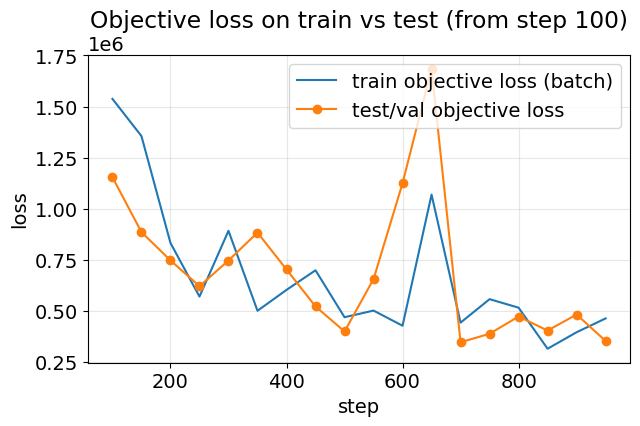

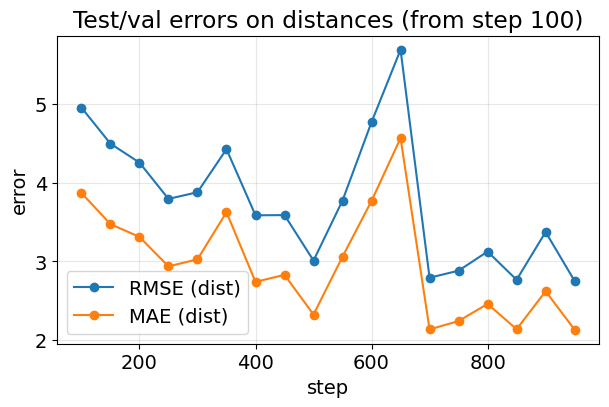

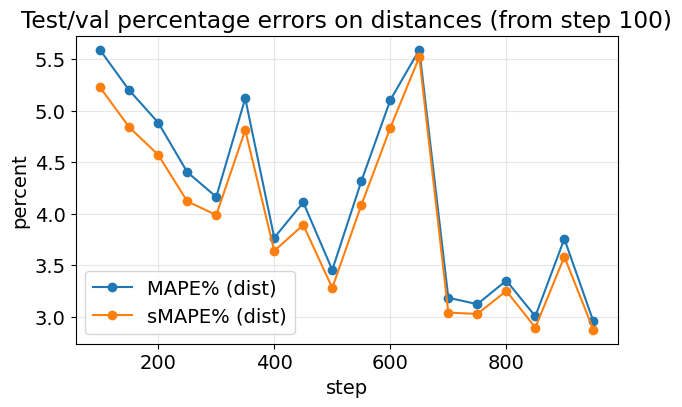

Best by VAL LOSS: step=700 val_loss=346588.812500
  [best val dist] RMSE=2.793 MAE=2.138 MAPE=3.18% sMAPE=3.04% Pearson=0.9980 Spearman=0.9979
[LM] FINAL test objective loss=344291.968750
[LM] FINAL test distances: RMSE=2.773 MAE=2.131 MAPE=3.16% sMAPE=3.02% Pearson=0.9980 Spearman=0.9979
------------------------------
[Vision] X_tr=(1404, 3584), X_te=(351, 3584), dim=3584
Init A = alpha*I, alpha=7.740572, ||A||=463.4012
step=50/1500 train_loss(batch)=19360168.000000 ||grad||=2018502.250 ||A||=464.521
  [val objective] loss=16968128.000000
  [val dist] RMSE=16.971 MAE=13.156 MAPE=17.31% sMAPE=15.21% Pearson=0.9250 Spearman=0.9321
step=100/1500 train_loss(batch)=6777116.000000 ||grad||=1500686.375 ||A||=466.274
  [val objective] loss=5601024.000000
  [val dist] RMSE=10.212 MAE=7.861 MAPE=10.68% sMAPE=9.75% Pearson=0.9741 Spearman=0.9739
step=150/1500 train_loss(batch)=4975395.500000 ||grad||=909641.938 ||A||=467.533
  [val objective] loss=2969081.750000
  [val dist] RMSE=7.760 MAE=5.969

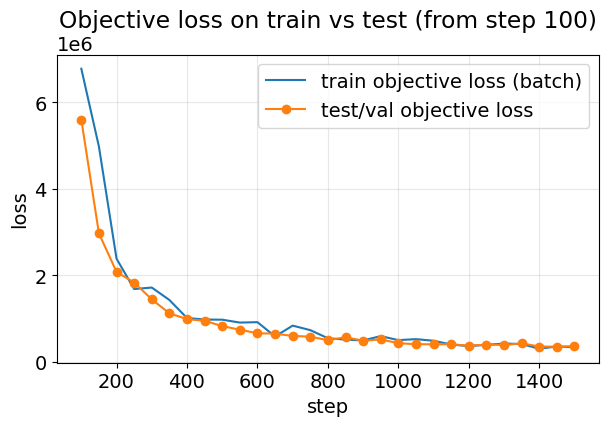

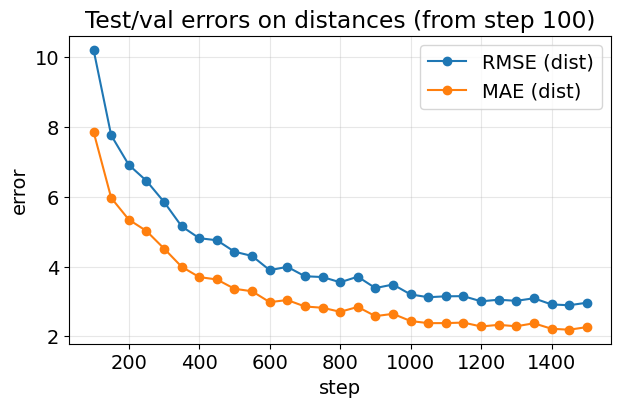

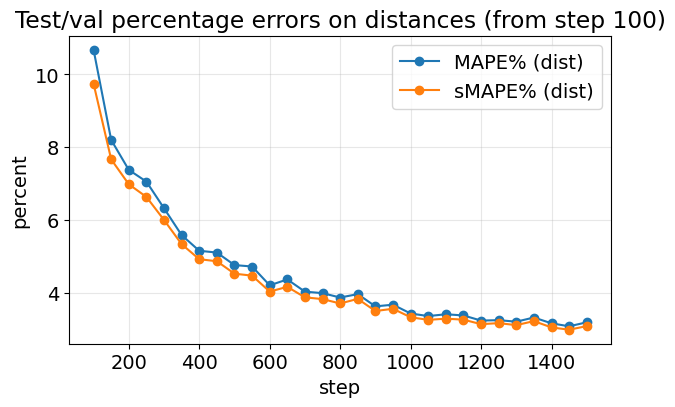

Best by VAL LOSS: step=1450 val_loss=350019.062500
  [best val dist] RMSE=2.892 MAE=2.190 MAPE=3.07% sMAPE=2.98% Pearson=0.9977 Spearman=0.9976
[Vision] FINAL test objective loss=348335.562500
[Vision] FINAL test distances: RMSE=2.871 MAE=2.174 MAPE=3.08% sMAPE=2.98% Pearson=0.9978 Spearman=0.9976


In [31]:
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt


# ============================================================
# 0) Utils
# ============================================================

def sanitize_XY(X, Y):
    X = np.asarray(X, dtype=np.float32)
    Y = np.asarray(Y, dtype=np.float32)
    m = np.isfinite(X).all(axis=1) & np.isfinite(Y).all(axis=1)
    if m.sum() < len(m):
        print(f"sanitize: dropped {len(m)-m.sum()}/{len(m)} rows with NaN/Inf")
    return X[m], Y[m]

def sample_pairs_uniform(n, n_pairs, rng):
    i = rng.integers(0, n, size=n_pairs, endpoint=False)
    j = rng.integers(0, n, size=n_pairs, endpoint=False)
    eq = (i == j)
    while np.any(eq):
        j[eq] = rng.integers(0, n, size=np.sum(eq), endpoint=False)
        eq = (i == j)
    i2 = np.minimum(i, j)
    j2 = np.maximum(i, j)
    return i2, j2

def make_pair_batch(X, Y, i, j):
    """
    returns:
      V:  (B,n) = X[i]-X[j]
      t2: (B,)  = ||Y[i]-Y[j]||^2
    """
    V = X[i] - X[j]
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    m = np.isfinite(V).all(axis=1) & np.isfinite(t2)
    if not np.all(m):
        V = V[m]
        t2 = t2[m]
    return V, t2

def compute_pred_true_for_pairs(X, Y, A, i, j):
    """
    returns arrays:
      t  = ||Δy||,  pred = ||AΔx||
      t2 = ||Δy||^2, pred2=||AΔx||^2
    """
    dY = Y[i] - Y[j]
    t2 = np.sum(dY * dY, axis=1)
    t = np.sqrt(np.maximum(t2, 0.0))

    dX = X[i] - X[j]
    AdX = dX @ A.T
    pred2 = np.sum(AdX * AdX, axis=1)
    pred = np.sqrt(np.maximum(pred2, 0.0))

    m = np.isfinite(t) & np.isfinite(pred) & np.isfinite(t2) & np.isfinite(pred2)
    return t[m], pred[m], t2[m], pred2[m]


# ============================================================
# 1) Objective for FULL A (n x n): squared-distances objective
#    L = mean ( ||A v||^2 - t2 )^2
# ============================================================

def loss_and_grad_A_squared_full(A, V, t2):
    AV = V @ A.T
    s = np.sum(AV * AV, axis=1)            # ||A v||^2
    e = (s - t2)                           # (B,)
    loss = float(np.mean(e * e))

    c = (4.0 * e).astype(np.float32)       # (B,)
    grad = ((c[:, None] * AV).T @ V) / max(1, V.shape[0])   # (n,n)
    return loss, grad


# ============================================================
# 2) AdamW (float32) + grad clipping
# ============================================================

class AdamW:
    def __init__(self, shape, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-4):
        self.lr = float(lr)
        self.b1 = float(beta1)
        self.b2 = float(beta2)
        self.eps = float(eps)
        self.wd = float(weight_decay)
        self.m = np.zeros(shape, dtype=np.float32)
        self.v = np.zeros(shape, dtype=np.float32)
        self.t = 0

    def step(self, param, grad):
        self.t += 1
        if self.wd > 0:
            param = param * (1.0 - self.lr * self.wd)

        self.m = self.b1 * self.m + (1 - self.b1) * grad
        self.v = self.b2 * self.v + (1 - self.b2) * (grad * grad)

        mhat = self.m / (1 - self.b1 ** self.t)
        vhat = self.v / (1 - self.b2 ** self.t)

        param = param - self.lr * mhat / (np.sqrt(vhat) + self.eps)
        return param


# ============================================================
# 3) Metrics on DISTANCES (not squared)
# ============================================================

def dist_errors(d_true, d_pred, eps=1e-6):
    d_true = np.asarray(d_true, dtype=np.float64)
    d_pred = np.asarray(d_pred, dtype=np.float64)

    err = d_pred - d_true
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err * err)))

    denom = np.maximum(np.abs(d_true), eps)
    mape = float(np.mean(np.abs(err) / denom) * 100.0)
    smape = float(np.mean(2.0 * np.abs(err) / np.maximum(np.abs(d_true) + np.abs(d_pred), eps)) * 100.0)

    pr = float(pearsonr(d_true, d_pred)[0])
    sr = spearmanr(d_true, d_pred)
    sr_r = float(getattr(sr, "correlation", sr.statistic))

    return {"rmse": rmse, "mae": mae, "mape": mape, "smape": smape, "pearson": pr, "spearman": sr_r}

def estimate_val_loss_sq_objective(X, Y, A, n_eval_pairs=80_000, seed=0):
    """
    Objective loss in training units:
      mean( (||AΔx||^2 - ||Δy||^2)^2 )
    """
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    V, t2 = make_pair_batch(X, Y, i, j)
    AV = V @ A.T
    pred2 = np.sum(AV * AV, axis=1)
    e = pred2 - t2
    return float(np.mean(e * e))

def eval_dist_metrics(X, Y, A, n_eval_pairs=80_000, seed=0):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_eval_pairs, rng)
    d_true, d_pred, _, _ = compute_pred_true_for_pairs(X, Y, A, i, j)
    return dist_errors(d_true, d_pred)


# ============================================================
# 4) Init: A = alpha * I
# ============================================================

def init_alphaI(X, Y, n_pairs=120_000, seed=0, eps=1e-12):
    rng = np.random.default_rng(seed)
    n = X.shape[0]
    i, j = sample_pairs_uniform(n, n_pairs, rng)

    dx = X[i] - X[j]
    dx2 = np.sum(dx * dx, axis=1)     # ||Δx||^2
    dy = Y[i] - Y[j]
    dy2 = np.sum(dy * dy, axis=1)     # ||Δy||^2

    num = float(np.dot(dy2, dx2))
    den = float(np.dot(dx2, dx2)) + eps
    alpha2 = max(num / den, 0.0)
    return float(np.sqrt(alpha2))


# ============================================================
# 5) Training loop
#    - best step by VAL objective loss
#    - plots:
#        (a) train vs val objective loss (from plot_from_step)
#        (b) distance metrics (RMSE/MAE/MAPE/sMAPE) on val (from plot_from_step)
# ============================================================

def fit_fullA_distance_squares(
    X_train, Y_train, X_val, Y_val,
    n_steps=1200,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    seed=42,
    log_every=50,
    val_every=200,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
):
    rng = np.random.default_rng(seed)
    n_dim = X_train.shape[1]

    alpha = init_alphaI(X_train, Y_train, n_pairs=120_000, seed=seed + 1)
    A = (alpha * np.eye(n_dim, dtype=np.float32))
    print(f"Init A = alpha*I, alpha={alpha:.6f}, ||A||={np.linalg.norm(A):.4f}")

    opt = AdamW(A.shape, lr=lr, weight_decay=weight_decay)

    i_all, j_all = sample_pairs_uniform(X_train.shape[0], n_pairs, rng)
    n_batches = int(np.ceil(n_pairs / batch_size))

    # histories
    hist_train_steps, hist_train_loss = [], []
    hist_val_steps, hist_val_loss = [], []

    # distance metrics histories (val only)
    hist_val_rmse, hist_val_mae, hist_val_mape, hist_val_smape = [], [], [], []

    best = {"val_loss": np.inf, "A": A.copy(), "step": 0, "val_dist": None}
    bad_count = 0

    for step in range(1, n_steps + 1):
        b = (step - 1) % n_batches
        sl = slice(b * batch_size, min((b + 1) * batch_size, n_pairs))
        i, j = i_all[sl], j_all[sl]

        V, t2 = make_pair_batch(X_train, Y_train, i, j)
        train_loss, grad = loss_and_grad_A_squared_full(A, V, t2)

        gnorm = float(np.linalg.norm(grad))
        if grad_clip is not None and gnorm > grad_clip:
            grad = grad * (grad_clip / (gnorm + 1e-12))

        if not (np.isfinite(train_loss) and np.isfinite(A).all() and np.isfinite(grad).all()):
            raise FloatingPointError(
                f"Non-finite at step={step}: train_loss={train_loss}, ||A||={np.linalg.norm(A)}"
            )

        A = opt.step(A, grad.astype(np.float32))

        if step % log_every == 0 or step == 1:
            hist_train_steps.append(step)
            hist_train_loss.append(train_loss)

        if step % val_every == 0 or step == n_steps:
            val_loss = estimate_val_loss_sq_objective(
                X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step
            )
            val_dist = eval_dist_metrics(
                X_val, Y_val, A, n_eval_pairs=n_val_pairs, seed=seed + step + 11
            )

            hist_val_steps.append(step)
            hist_val_loss.append(val_loss)

            hist_val_rmse.append(val_dist["rmse"])
            hist_val_mae.append(val_dist["mae"])
            hist_val_mape.append(val_dist["mape"])
            hist_val_smape.append(val_dist["smape"])

            print(f"step={step}/{n_steps} train_loss(batch)={train_loss:.6f} ||grad||={gnorm:.3f} ||A||={np.linalg.norm(A):.3f}")
            print(f"  [val objective] loss={val_loss:.6f}")
            print(f"  [val dist] RMSE={val_dist['rmse']:.3f} MAE={val_dist['mae']:.3f} "
                  f"MAPE={val_dist['mape']:.2f}% sMAPE={val_dist['smape']:.2f}% "
                  f"Pearson={val_dist['pearson']:.4f} Spearman={val_dist['spearman']:.4f}")

            if val_loss < best["val_loss"] - min_delta:
                best = {"val_loss": val_loss, "A": A.copy(), "step": step, "val_dist": val_dist}
                bad_count = 0
            else:
                bad_count += 1
                if bad_count >= patience:
                    print(f"Early stopping at step={step}: no improvement in VAL LOSS for {patience} validations. "
                          f"Best step={best['step']} val_loss={best['val_loss']:.6f}")
                    break

    # ---------- plots ----------
    tr_s = np.array(hist_train_steps, dtype=int)
    tr_l = np.array(hist_train_loss, dtype=float)
    va_s = np.array(hist_val_steps, dtype=int)
    va_l = np.array(hist_val_loss, dtype=float)

    m_tr = tr_s >= plot_from_step
    m_va = va_s >= plot_from_step

    # NEW: train + test(=val) objective loss on one plot
    plt.figure(figsize=(7, 4))
    if m_tr.any():
        plt.plot(tr_s[m_tr], tr_l[m_tr], label="train objective loss (batch)")
    if m_va.any():
        plt.plot(va_s[m_va], va_l[m_va], marker="o", label="test/val objective loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title(f"Objective loss on train vs test (from step {plot_from_step})")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

    # distance metrics (only distances)
    if len(hist_val_steps) > 0:
        m_va = va_s >= plot_from_step
        if m_va.any():
            plt.figure(figsize=(7, 4))
            plt.plot(va_s[m_va], np.array(hist_val_rmse)[m_va], marker="o", label="RMSE (dist)")
            plt.plot(va_s[m_va], np.array(hist_val_mae)[m_va], marker="o", label="MAE (dist)")
            plt.xlabel("step")
            plt.ylabel("error")
            plt.title(f"Test/val errors on distances (from step {plot_from_step})")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

            plt.figure(figsize=(7, 4))
            plt.plot(va_s[m_va], np.array(hist_val_mape)[m_va], marker="o", label="MAPE% (dist)")
            plt.plot(va_s[m_va], np.array(hist_val_smape)[m_va], marker="o", label="sMAPE% (dist)")
            plt.xlabel("step")
            plt.ylabel("percent")
            plt.title(f"Test/val percentage errors on distances (from step {plot_from_step})")
            plt.grid(True, alpha=0.3)
            plt.legend()
            plt.show()

    print(f"Best by VAL LOSS: step={best['step']} val_loss={best['val_loss']:.6f}")
    if best["val_dist"] is not None:
        d = best["val_dist"]
        print(f"  [best val dist] RMSE={d['rmse']:.3f} MAE={d['mae']:.3f} "
              f"MAPE={d['mape']:.2f}% sMAPE={d['smape']:.2f}% "
              f"Pearson={d['pearson']:.4f} Spearman={d['spearman']:.4f}")

    history = {
        "train_steps": tr_s,
        "train_loss": tr_l,
        "val_steps": va_s,
        "val_loss": va_l,
        "val_dist_rmse": np.array(hist_val_rmse, dtype=float),
        "val_dist_mae": np.array(hist_val_mae, dtype=float),
        "val_dist_mape": np.array(hist_val_mape, dtype=float),
        "val_dist_smape": np.array(hist_val_smape, dtype=float),
    }
    return best, history


# ============================================================
# 6) End-to-end runner
# ============================================================

def run_fullA_experiment(
    embeddings, Y_cam,
    layer_name="LM",
    test_size=0.2,
    random_state=42,
    n_steps=1500,
    n_pairs=400_000,
    batch_size=512,
    lr=3e-4,
    weight_decay=3e-4,
    grad_clip=5.0,
    val_every=50,
    n_val_pairs=80_000,
    patience=5,
    min_delta=0.0,
    plot_from_step=100,
):
    X, Y = sanitize_XY(embeddings, Y_cam)

    X_tr, X_te, Y_tr, Y_te = train_test_split(
        X, Y, test_size=test_size, random_state=random_state
    )

    print(f"[{layer_name}] X_tr={X_tr.shape}, X_te={X_te.shape}, dim={X_tr.shape[1]}")

    best, history = fit_fullA_distance_squares(
        X_tr, Y_tr, X_te, Y_te,
        n_steps=n_steps,
        n_pairs=n_pairs,
        batch_size=batch_size,
        lr=lr,
        weight_decay=weight_decay,
        grad_clip=grad_clip,
        seed=42,
        log_every=50,
        val_every=val_every,
        n_val_pairs=n_val_pairs,
        patience=patience,
        min_delta=min_delta,
        plot_from_step=plot_from_step,
    )

    A_best = best["A"]

    final_loss = estimate_val_loss_sq_objective(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=999)
    final_dist = eval_dist_metrics(X_te, Y_te, A_best, n_eval_pairs=200_000, seed=1002)

    print(f"[{layer_name}] FINAL test objective loss={final_loss:.6f}")
    print(f"[{layer_name}] FINAL test distances: "
          f"RMSE={final_dist['rmse']:.3f} MAE={final_dist['mae']:.3f} "
          f"MAPE={final_dist['mape']:.2f}% sMAPE={final_dist['smape']:.2f}% "
          f"Pearson={final_dist['pearson']:.4f} Spearman={final_dist['spearman']:.4f}")

    return {"A": A_best, "best": best, "history": history, "final": {"loss": final_loss, "dist": final_dist}}


# ============================================================
# Usage:
out_lm = run_fullA_experiment(lm, cam, layer_name="LM")
print("-" * 30)
out_vl = run_fullA_experiment(vl, cam, layer_name="Vision")
# ============================================================


## Сравнили полученную метрику по STRESS метрике

In [ ]:
from vsl_ial.stress import stress, mean_stress, group_stress
import numpy as np

def build_pair_indices(n, max_pairs=None, seed=42):
    i_all, j_all = np.triu_indices(n, k=1)
    if max_pairs is not None and max_pairs < i_all.size:
        rng = np.random.default_rng(seed)
        sel = rng.choice(i_all.size, size=max_pairs, replace=False)
        i_all, j_all = i_all[sel], j_all[sel]
    return i_all, j_all

def pairwise_distance_arrays(X, Y, A, pair_idx=None, chunk_size=20_000):
    """
    d_emb_A = ||A(x_i - x_j)||
    d_cam   = ||y_i - y_j||
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    A = np.asarray(A, dtype=np.float64)

    n = X.shape[0]
    if pair_idx is None:
        i_all, j_all = np.triu_indices(n, k=1)
    else:
        i_all, j_all = pair_idx
        # safety
        if i_all.max() >= n or j_all.max() >= n:
            raise ValueError(f"pair_idx out of bounds: max_i={i_all.max()}, max_j={j_all.max()}, n={n}")

    d_emb_A = np.empty(i_all.shape[0], dtype=np.float64)
    d_cam   = np.empty(i_all.shape[0], dtype=np.float64)

    for s in range(0, i_all.shape[0], chunk_size):
        e = min(s + chunk_size, i_all.shape[0])
        i, j = i_all[s:e], j_all[s:e]

        dX  = X[i] - X[j]
        AdX = dX @ A.T
        d_emb_A[s:e] = np.sqrt(np.maximum(np.sum(AdX * AdX, axis=1), 0.0))

        dY = Y[i] - Y[j]
        d_cam[s:e] = np.sqrt(np.maximum(np.sum(dY * dY, axis=1), 0.0))

    m = np.isfinite(d_emb_A) & np.isfinite(d_cam)
    return d_emb_A[m], d_cam[m]

X_lm, Y_cam_lm = sanitize_XY(lm, cam)
X_vl, Y_cam_vl = sanitize_XY(vl, cam)

assert X_lm.shape[0] == X_vl.shape[0] == Y_cam_lm.shape[0] == Y_cam_vl.shape[0], \
    (X_lm.shape, X_vl.shape, Y_cam_lm.shape, Y_cam_vl.shape)

n = Y_cam_lm.shape[0]
pair_idx = build_pair_indices(n=n, max_pairs=None, seed=42)  

d_emb_A_lm, d_cam = pairwise_distance_arrays(X_lm, Y_cam_lm, out_lm["A"], pair_idx=pair_idx)
d_emb_A_vl, _     = pairwise_distance_arrays(X_vl, Y_cam_vl, out_vl["A"], pair_idx=pair_idx)

print(f"Stress LM (ord=2):     {stress(d_emb_A_lm, d_cam, ord=2):.6f}")
print(f"Stress Vision (ord=2): {stress(d_emb_A_vl, d_cam, ord=2):.6f}")


Stress LM (ord=2):     0.026299
Stress Vision (ord=2): 0.026517


In [ ]:
from vsl_ial.eval.dataset import DatasetCombvd
import pandas as pd

# создаём конфигурацию
combvd_cfg = DatasetCombvd(name="combvd", weight=1.0)

# загружаем
weighted = combvd_cfg.load()

datasets = weighted.datasets
name = weighted.name
weight = weighted.weight

print(f"Loaded dataset: {name}, weight={weight}")
print("Number of sub-datasets:", len(datasets))

# посмотреть первые элементы
for ds in datasets[:2]:
    print(ds)  # DistanceDataset с метаданными и примерами


Loaded dataset: combvd, weight=1.0
Number of sub-datasets: 6
DistanceDataset(name='witt', L_A=82.8, Y_b=24.9, c=0.69, Nc=1, F=1, illuminant=array([0.9481, 1.    , 1.0733]), xyz=array([[0.08289695, 0.0816    , 0.2169892 ],
       [0.08289706, 0.0816    , 0.2169897 ],
       [0.08289719, 0.0816    , 0.21698995],
       ...,
       [0.66788645, 0.7386    , 0.32244558],
       [0.667887  , 0.7386    , 0.322446  ],
       [0.66788714, 0.7386    , 0.32244571]], shape=(538, 3)), pairs=[[482, 477], [482, 487], [482, 475], [482, 473], [482, 471], [482, 485], [482, 499], [482, 496], [482, 494], [482, 502], [482, 481], [482, 506], [482, 513], [482, 517], [482, 521], [482, 469], [482, 464], [482, 459], [482, 455], [482, 447], [482, 510], [482, 525], [482, 529], [482, 533], [482, 537], [482, 491], [482, 451], [482, 442], [482, 438], [482, 434], [371, 358], [371, 347], [371, 370], [371, 375], [371, 373], [371, 345], [371, 378], [371, 391], [371, 388], [371, 385], [371, 356], [371, 397], [371, 382], 